# 🌉 Small-Scale Concrete Bridge — Structural Health Monitoring
**Sensors:** MPU-6050 (Accelerometer + Gyroscope) + SW-420 Vibration Switch  
**Duration:** ~58 minutes | **Sampling:** ~4 Hz (irregular)  

### What this notebook covers
1. Data Loading & Preprocessing
2. Exploratory Data Analysis (EDA)
3. Signal Processing (FFT, filtering)
4. Feature Engineering
5. Anomaly Detection (Isolation Forest + Z-Score)
6. Vibration Event Analysis (SW-420)
7. Structural Health Index (SHI) — a composite score
8. ML Classification: Normal vs Anomalous
9. PCA Visualization
10. Dashboard Summary

## 0. Install dependencies (run once)

In [ ]:
# Uncomment if needed
# !pip install pandas numpy matplotlib seaborn scipy scikit-learn

## 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import signal
from scipy.fft import fft, fftfreq
from scipy.stats import zscore, kurtosis, skew
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor': '#1a1a2e',
    'axes.edgecolor': '#444466',
    'axes.labelcolor': '#ccccee',
    'xtick.color': '#aaaacc',
    'ytick.color': '#aaaacc',
    'text.color': '#ccccee',
    'grid.color': '#2a2a4a',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'legend.facecolor': '#1a1a2e',
    'legend.edgecolor': '#444466',
    'figure.dpi': 120
})

ACCEL_COLS = ['ax', 'ay', 'az']
GYRO_COLS  = ['gx', 'gy', 'gz']
SENSOR_COLS = ACCEL_COLS + GYRO_COLS

COLORS = {
    'ax': '#ff6b6b', 'ay': '#ffd93d', 'az': '#6bcb77',
    'gx': '#4d96ff', 'gy': '#c77dff', 'gz': '#ff9f1c',
    'vibration': '#ff6b6b', 'normal': '#6bcb77',
    'anomaly': '#ff3366', 'shi': '#4d96ff'
}

# ← UPDATE THIS PATH if your file is elsewhere
DATA_PATH = 'sensor_data6.csv'

print('✅ Imports done.')

✅ Imports done.


## 2. Data Loading & Preprocessing

In [2]:
# ── Load ──────────────────────────────────────────────────────────────────────
# Row 0 is a duplicate header row from the logger — skip it
raw = pd.read_csv(DATA_PATH, skiprows=1)
raw.columns = ['timestamp', 'ax', 'ay', 'az', 'gx', 'gy', 'gz', 'sw420']

# ── Parse timestamps ──────────────────────────────────────────────────────────
# Format: HH:MM:SS:mmm  (colon-separated milliseconds)
def parse_ts(ts):
    parts = ts.split(':')
    h, m, s, ms = int(parts[0]), int(parts[1]), int(parts[2]), int(parts[3])
    return h*3600 + m*60 + s + ms/1000.0

raw['time_sec'] = raw['timestamp'].apply(parse_ts)
t0 = raw['time_sec'].iloc[0]
raw['elapsed_sec'] = raw['time_sec'] - t0

# ── Clip MPU-6050 saturation artefacts ────────────────────────────────────────
# ±32768 raw values = sensor overflow / spike — replace with NaN then interpolate
for col in SENSOR_COLS:
    sat_mask = (raw[col] == 32767) | (raw[col] == -32768)
    raw.loc[sat_mask, col] = np.nan

n_sat = raw[SENSOR_COLS].isna().sum().sum()
raw[SENSOR_COLS] = raw[SENSOR_COLS].interpolate(method='linear')

df = raw.reset_index(drop=True)

duration_min = df['elapsed_sec'].max() / 60
avg_fs = len(df) / df['elapsed_sec'].max()

print(f"Rows          : {len(df):,}")
print(f"Duration      : {duration_min:.1f} min")
print(f"Avg sample rate: {avg_fs:.1f} Hz")
print(f"Saturated pts removed: {n_sat}")
print(f"Vibration events (SW-420=1): {df['sw420'].sum()} ({df['sw420'].mean()*100:.1f}%)")
df[SENSOR_COLS + ['sw420']].describe().round(1)

Rows          : 13,750
Duration      : 57.8 min
Avg sample rate: 4.0 Hz
Saturated pts removed: 15
Vibration events (SW-420=1): 705 (5.1%)


,ax,ay,az,gx,gy,gz,sw420
count,13750.0,13750.0,13750.0,13750.0,13750.0,13750.0,13750.0
mean,-232.3,-71.9,15016.4,-202.7,30.3,-132.6,0.1
std,747.7,449.3,1002.7,268.3,570.1,116.1,0.2
min,-26684.0,-12600.0,-24736.0,-21089.0,-19343.0,-6600.0,0.0
25%,-380.0,-140.0,14916.0,-213.0,11.0,-143.0,0.0
50%,-240.0,-80.0,14996.0,-203.0,23.0,-133.0,0.0
75%,-84.0,-12.0,15076.0,-193.0,35.0,-124.0,0.0
max,29824.0,29064.0,29316.0,12846.0,29591.0,6599.0,1.0


## 3. Exploratory Data Analysis

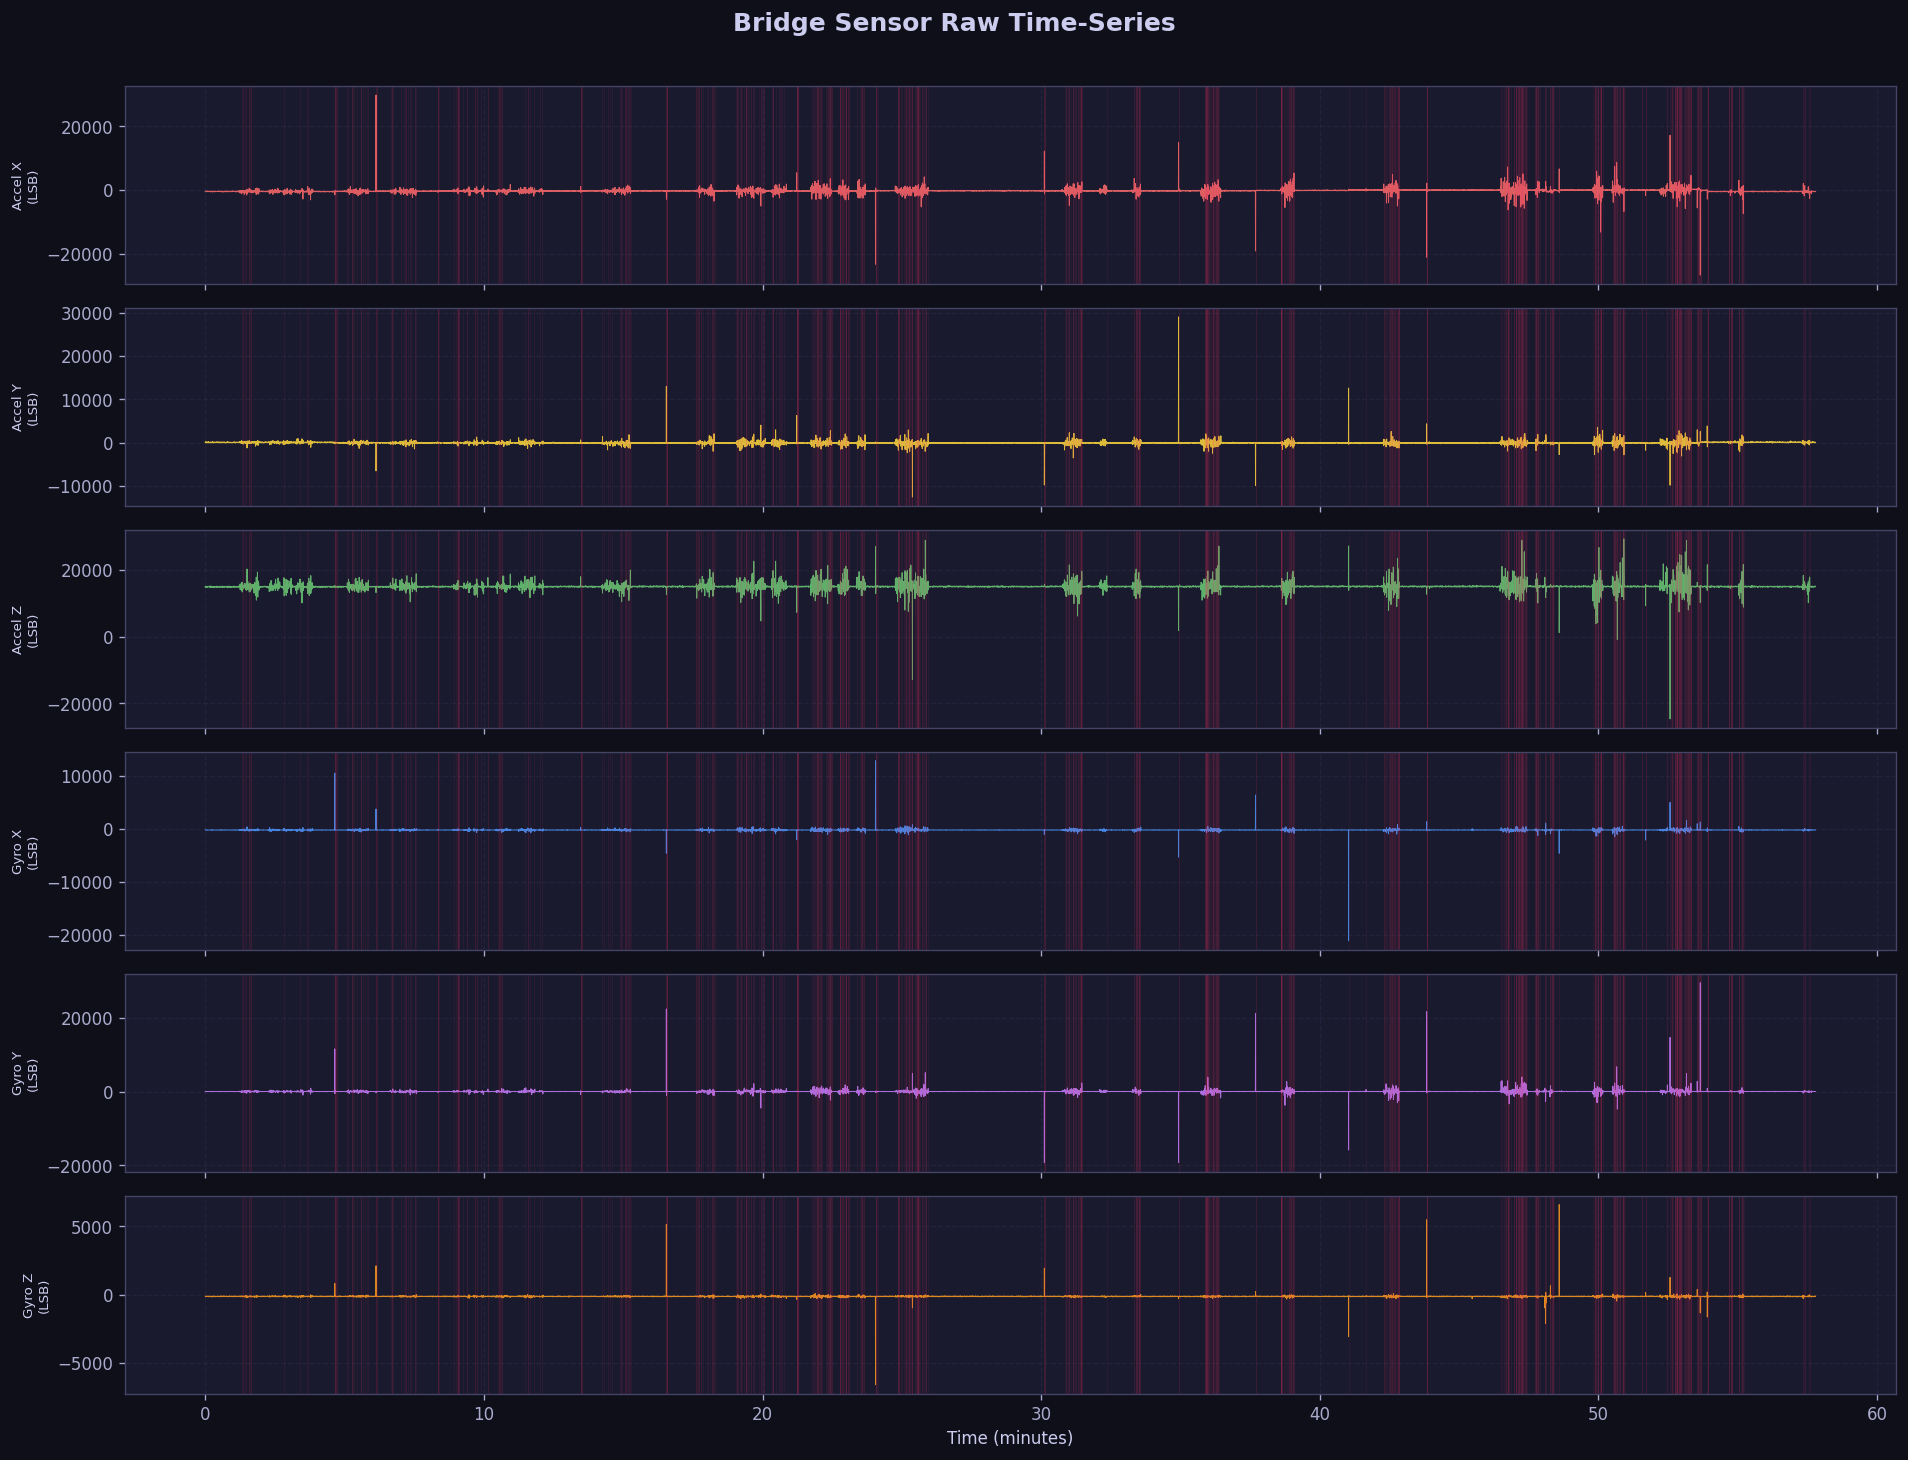

Red vertical lines = SW-420 vibration triggers


In [3]:
# ── 3A: Raw time-series for all 6 channels ────────────────────────────────────
fig, axes = plt.subplots(6, 1, figsize=(16, 12), sharex=True)
fig.suptitle('Bridge Sensor Raw Time-Series', fontsize=15, fontweight='bold', y=1.01)

labels = {'ax':'Accel X', 'ay':'Accel Y', 'az':'Accel Z',
          'gx':'Gyro X',  'gy':'Gyro Y',  'gz':'Gyro Z'}
units  = {**{c:'LSB' for c in ACCEL_COLS}, **{c:'LSB' for c in GYRO_COLS}}

for ax_obj, col in zip(axes, SENSOR_COLS):
    ax_obj.plot(df['elapsed_sec']/60, df[col], color=COLORS[col], lw=0.6, alpha=0.85)
    # shade vibration events
    vib_times = df[df['sw420']==1]['elapsed_sec']/60
    for vt in vib_times:
        ax_obj.axvline(vt, color='#ff3366', alpha=0.08, lw=0.5)
    ax_obj.set_ylabel(f'{labels[col]}\n({units[col]})', fontsize=8)
    ax_obj.grid(True)

axes[-1].set_xlabel('Time (minutes)')
plt.tight_layout()
plt.savefig('01_raw_timeseries.png', bbox_inches='tight', dpi=130)
plt.show()
print('Red vertical lines = SW-420 vibration triggers')

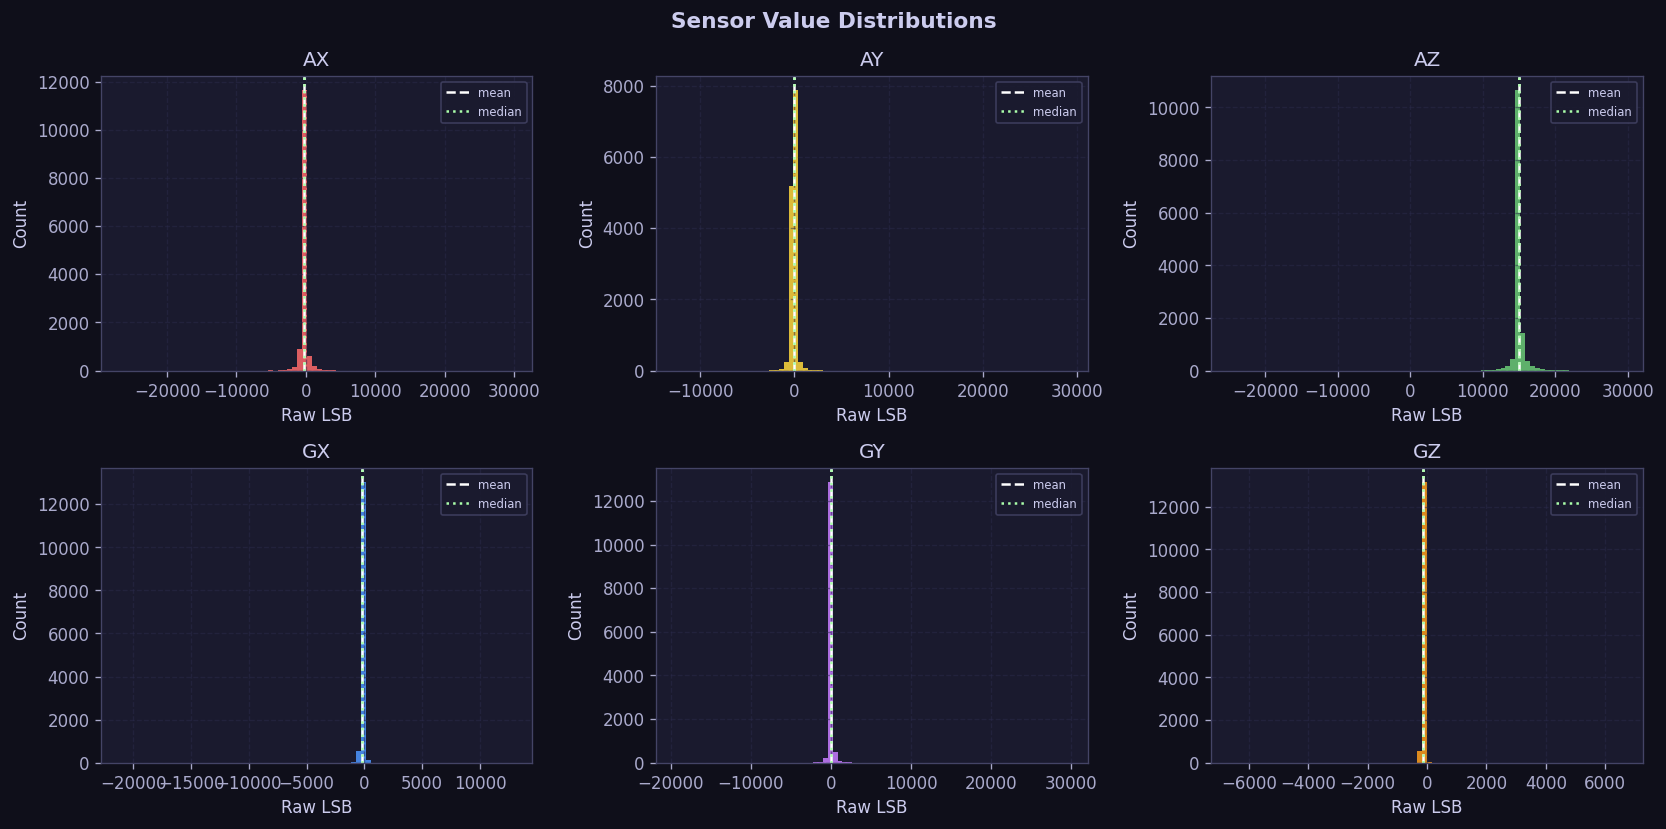

In [4]:
# ── 3B: Distribution of each channel ─────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.suptitle('Sensor Value Distributions', fontsize=13, fontweight='bold')

for ax_obj, col in zip(axes.flatten(), SENSOR_COLS):
    ax_obj.hist(df[col], bins=80, color=COLORS[col], edgecolor='none', alpha=0.85)
    ax_obj.axvline(df[col].mean(),  color='white',   lw=1.5, linestyle='--', label='mean')
    ax_obj.axvline(df[col].median(),color='#aaffaa', lw=1.5, linestyle=':',  label='median')
    ax_obj.set_title(col.upper())
    ax_obj.set_xlabel('Raw LSB')
    ax_obj.set_ylabel('Count')
    ax_obj.legend(fontsize=7)
    ax_obj.grid(True)

plt.tight_layout()
plt.savefig('02_distributions.png', bbox_inches='tight', dpi=130)
plt.show()

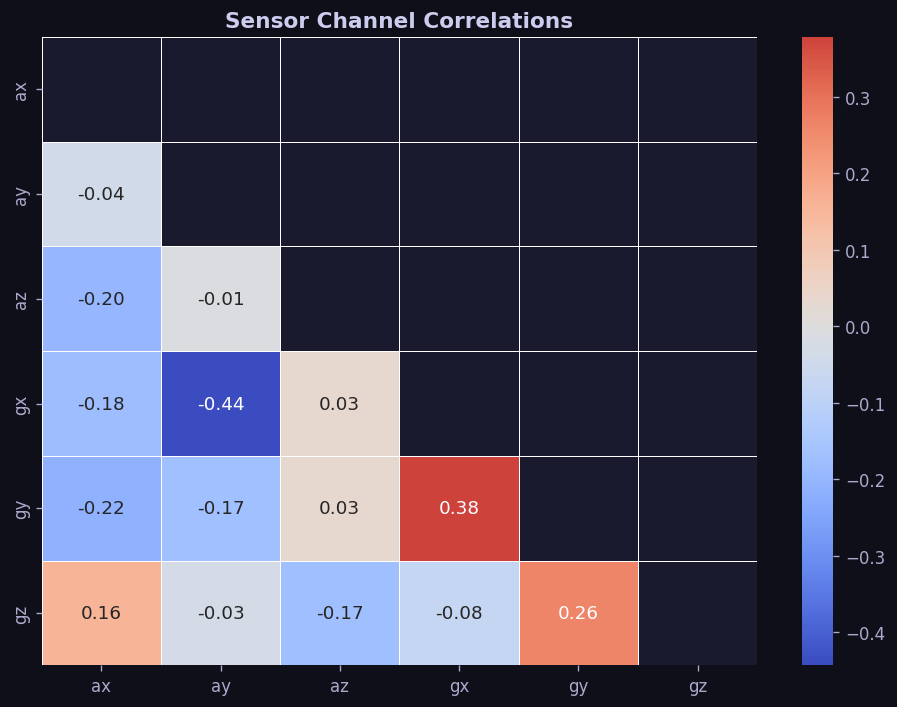

In [5]:
# ── 3C: Correlation heatmap ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[SENSOR_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', mask=mask,
            linewidths=0.5, ax=ax, center=0,
            annot_kws={'size': 11})
ax.set_title('Sensor Channel Correlations', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('03_correlation.png', bbox_inches='tight', dpi=130)
plt.show()

## 4. Signal Processing

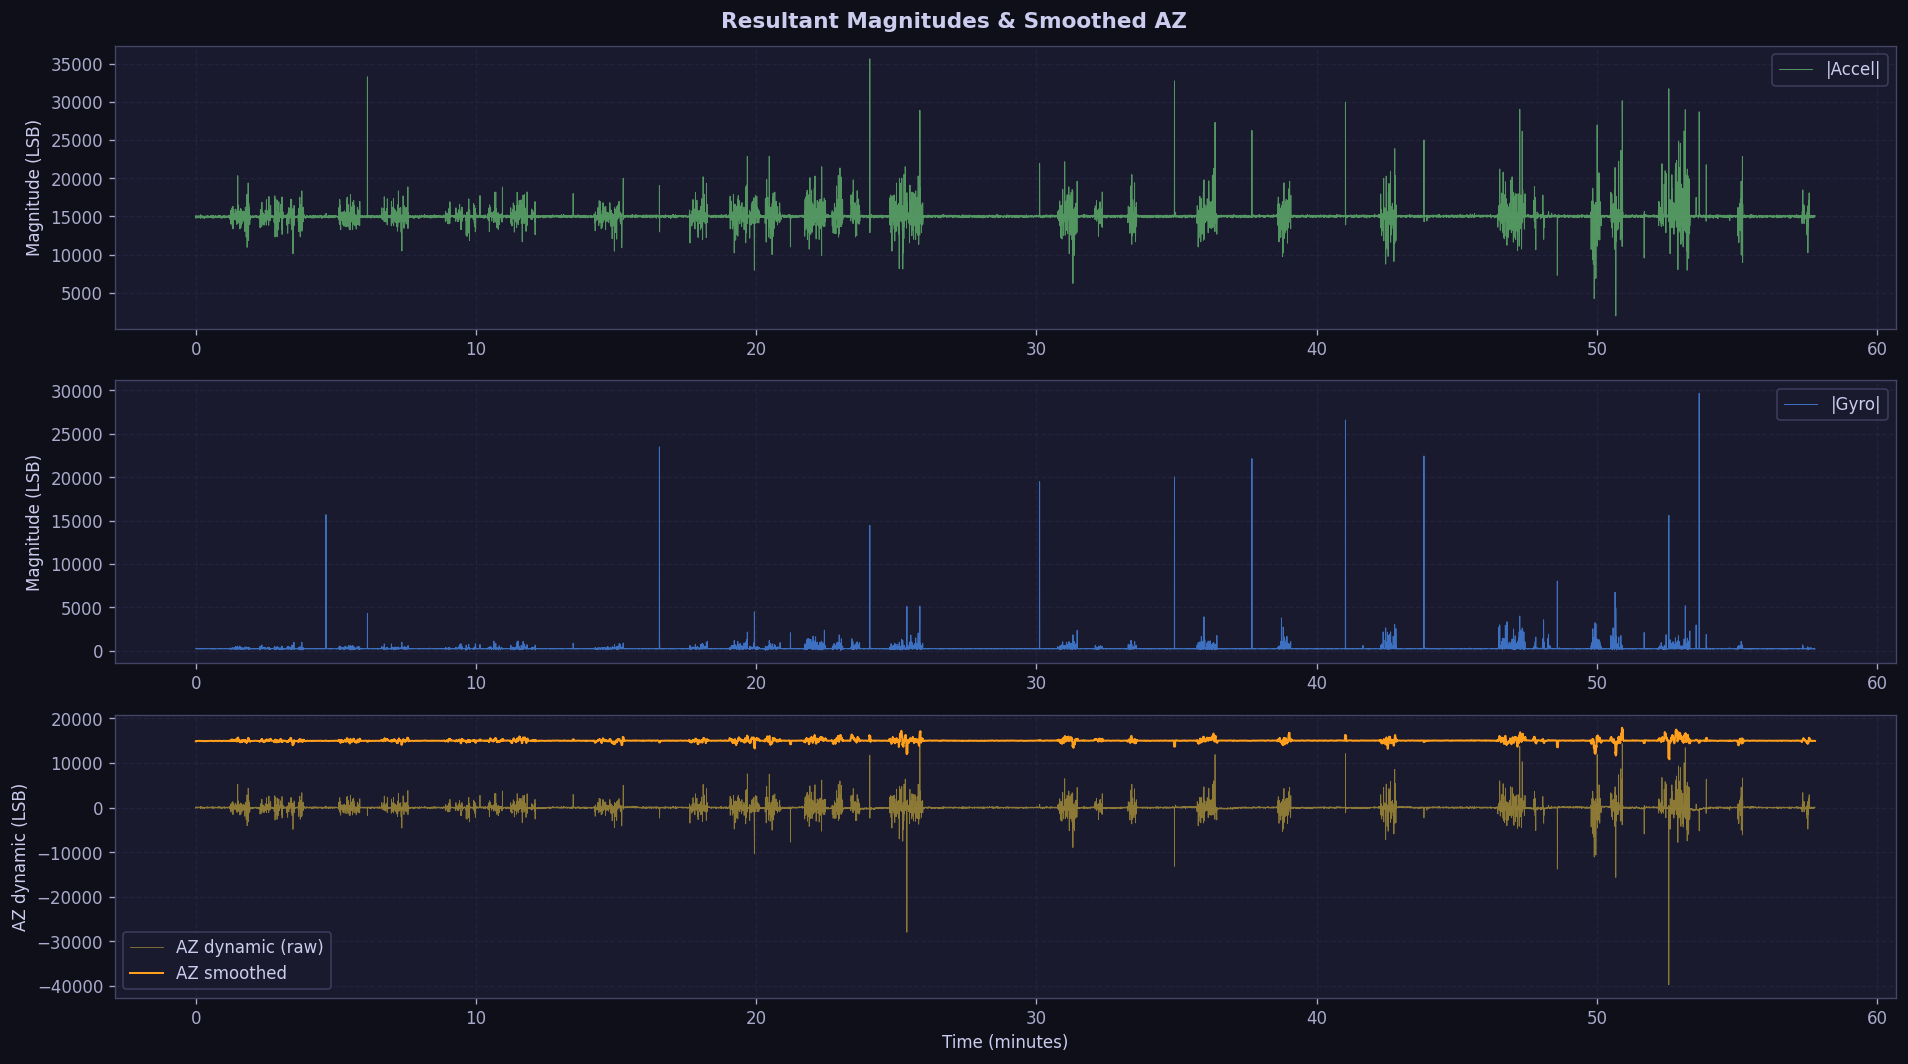

In [6]:
# ── 4A: Compute resultant acceleration (magnitude) ────────────────────────────
df['acc_mag'] = np.sqrt(df['ax']**2 + df['ay']**2 + df['az']**2)
df['gyr_mag'] = np.sqrt(df['gx']**2 + df['gy']**2 + df['gz']**2)

# Remove DC offset (gravity component in az)
df['az_dyn'] = df['az'] - df['az'].rolling(200, min_periods=1).mean()

# ── 4B: Low-pass Butterworth filter (5 Hz cutoff) ─────────────────────────────
FS = avg_fs  # ~4 Hz — use with caution, Nyquist = 2 Hz
# Because avg_fs ≈ 4 Hz, we can only see up to 2 Hz — still useful for trend
# We'll use a simple rolling mean as a low-pass proxy
WINDOW = 10
for col in SENSOR_COLS:
    df[f'{col}_smooth'] = df[col].rolling(WINDOW, center=True, min_periods=1).mean()

fig, axes = plt.subplots(3, 1, figsize=(16, 9))
fig.suptitle('Resultant Magnitudes & Smoothed AZ', fontsize=13, fontweight='bold')

t = df['elapsed_sec'] / 60
axes[0].plot(t, df['acc_mag'], color='#6bcb77', lw=0.6, alpha=0.7, label='|Accel|')
axes[0].set_ylabel('Magnitude (LSB)')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t, df['gyr_mag'], color='#4d96ff', lw=0.6, alpha=0.7, label='|Gyro|')
axes[1].set_ylabel('Magnitude (LSB)')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(t, df['az_dyn'],        color='#ffd93d', lw=0.5, alpha=0.5, label='AZ dynamic (raw)')
axes[2].plot(t, df['az_smooth'],     color='#ff9f1c', lw=1.2,            label='AZ smoothed')
axes[2].set_ylabel('AZ dynamic (LSB)')
axes[2].set_xlabel('Time (minutes)')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.savefig('04_magnitudes.png', bbox_inches='tight', dpi=130)
plt.show()

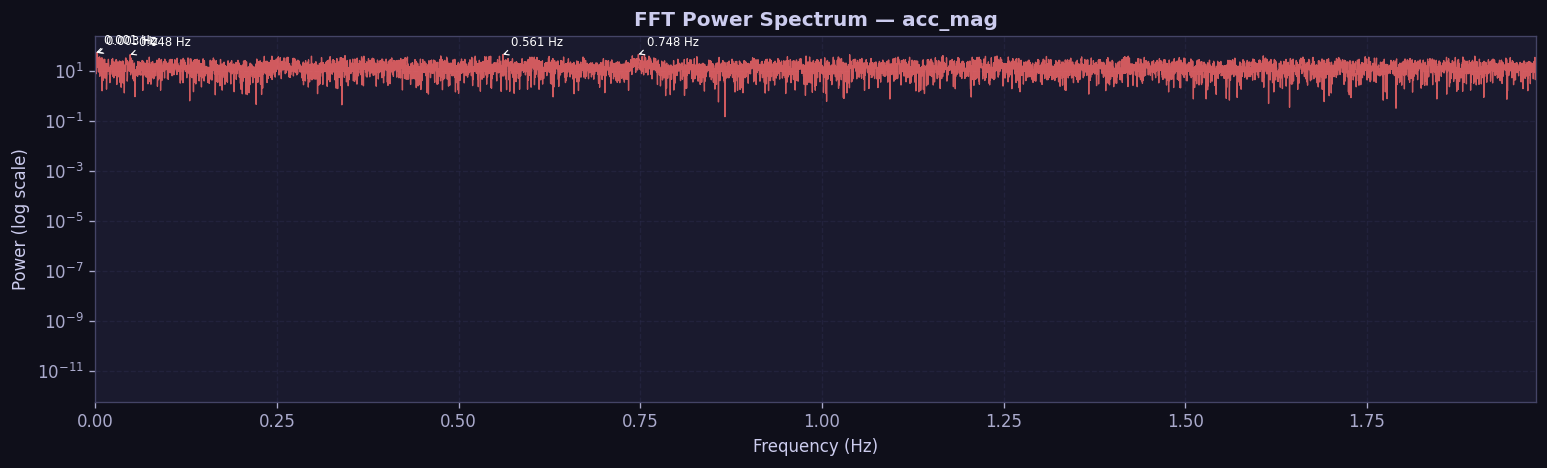

Top 5 dominant frequencies in acc_mag: [0.0012 0.0029 0.7475 0.0482 0.5609] Hz


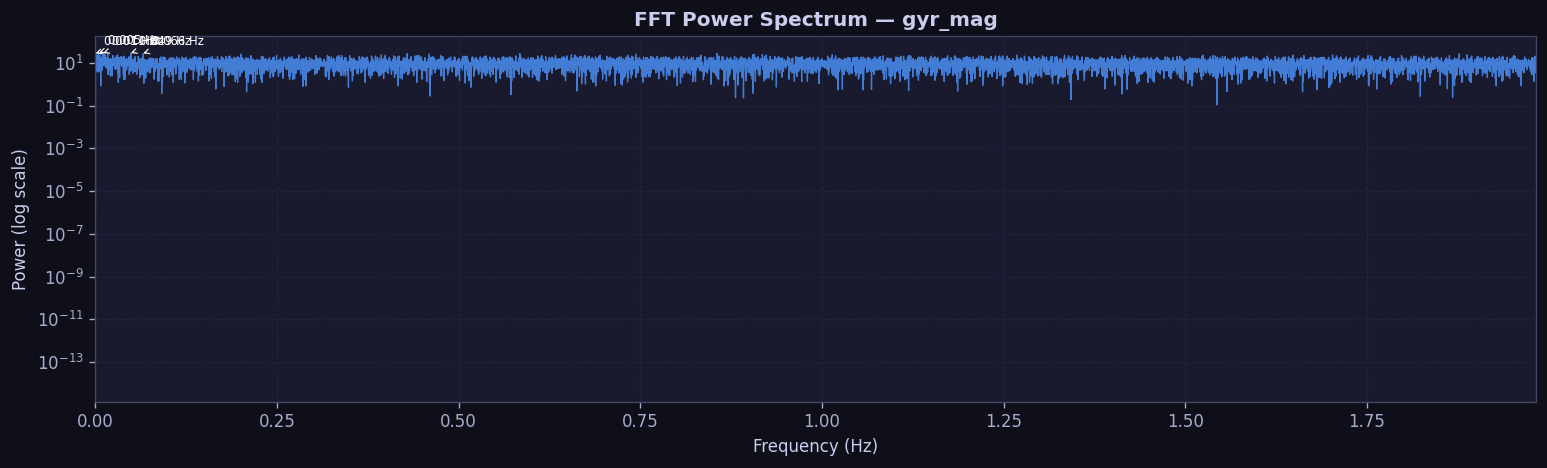

Top 5 dominant frequencies in gyr_mag: [0.0055 0.011  0.049  0.066  0.0006] Hz


In [7]:
# ── 4C: FFT — frequency content of acceleration magnitude ────────────────────
# Resample to uniform time grid for proper FFT
t_uniform = np.linspace(df['elapsed_sec'].iloc[0], df['elapsed_sec'].iloc[-1], len(df))
fs_uniform = len(df) / df['elapsed_sec'].max()   # effective fs after resampling

for sig_name, sig_data in [('acc_mag', df['acc_mag']), ('gyr_mag', df['gyr_mag'])]:
    N = len(sig_data)
    yf = fft(sig_data.values - sig_data.mean())
    xf = fftfreq(N, 1/fs_uniform)[:N//2]
    power = 2.0/N * np.abs(yf[:N//2])

    fig, ax = plt.subplots(figsize=(13, 4))
    ax.semilogy(xf, power, color=COLORS['ax'] if 'acc' in sig_name else COLORS['gx'],
                lw=0.8, alpha=0.8)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Power (log scale)')
    ax.set_title(f'FFT Power Spectrum — {sig_name}', fontsize=12, fontweight='bold')
    ax.set_xlim(0, fs_uniform/2)
    ax.grid(True)

    # Mark dominant frequencies
    top_idx = np.argsort(power)[-5:][::-1]
    for idx in top_idx:
        ax.annotate(f'{xf[idx]:.3f} Hz', xy=(xf[idx], power[idx]),
                    xytext=(5, 5), textcoords='offset points',
                    color='white', fontsize=7, arrowprops=dict(arrowstyle='->', color='white', lw=0.7))

    plt.tight_layout()
    plt.savefig(f'05_fft_{sig_name}.png', bbox_inches='tight', dpi=130)
    plt.show()
    print(f'Top 5 dominant frequencies in {sig_name}: {xf[top_idx].round(4)} Hz')

## 5. Feature Engineering

In [8]:
# Sliding window feature extraction
# Window = 50 samples (~12 sec at 4 Hz)

WINDOW_SIZE = 50
STEP        = 25   # 50% overlap

feature_rows = []

for start in range(0, len(df) - WINDOW_SIZE, STEP):
    end = start + WINDOW_SIZE
    w   = df.iloc[start:end]

    row = {'window_start': start, 'time_min': w['elapsed_sec'].mean() / 60}

    for col in SENSOR_COLS + ['acc_mag', 'gyr_mag']:
        s = w[col]
        row[f'{col}_mean']  = s.mean()
        row[f'{col}_std']   = s.std()
        row[f'{col}_rms']   = np.sqrt((s**2).mean())
        row[f'{col}_peak']  = s.abs().max()
        row[f'{col}_p2p']   = s.max() - s.min()          # peak-to-peak
        row[f'{col}_kurt']  = kurtosis(s)                 # impulsiveness
        row[f'{col}_skew']  = skew(s)                     # asymmetry
        row[f'{col}_crest'] = s.abs().max() / (np.sqrt((s**2).mean()) + 1e-9)  # crest factor

    # Vibration event ratio in window
    row['vib_ratio'] = w['sw420'].mean()
    row['vib_event'] = int(w['sw420'].sum() > 0)

    feature_rows.append(row)

feat_df = pd.DataFrame(feature_rows)
feat_cols = [c for c in feat_df.columns if c not in ['window_start', 'time_min', 'vib_ratio', 'vib_event']]

print(f'Feature matrix: {feat_df.shape[0]} windows × {len(feat_cols)} features')
feat_df[feat_cols[:12]].describe().round(2)

Feature matrix: 548 windows × 64 features


,ax_mean,ax_std,ax_rms,ax_peak,ax_p2p,ax_kurt,ax_skew,ax_crest,ay_mean,ay_std,ay_rms,ay_peak
count,548.00,548.00,548.00,548.00,548.00,548.00,548.00,548.00,548.00,548.00,548.00,548.00
mean,-231.47,404.10,538.68,2012.01,2578.62,5.11,-0.06,2.72,-72.33,242.57,274.19,1146.66
std,182.79,612.92,569.97,3781.07,4311.34,9.98,1.93,1.44,80.02,376.30,364.50,2486.63
min,-736.00,39.43,47.12,112.00,168.00,-0.98,-6.85,1.16,-448.32,41.23,48.94,96.00
25%,-356.43,55.01,227.64,352.00,248.00,-0.12,-0.50,1.50,-105.24,53.50,106.78,212.00
50%,-252.32,90.31,412.64,602.00,584.00,1.01,-0.03,2.44,-89.48,66.81,127.20,296.00
75%,-124.60,500.76,604.38,2077.00,3232.00,5.03,0.38,3.36,-47.58,317.12,332.14,1320.00
max,803.44,4276.28,4237.86,29824.00,30364.00,44.98,6.85,7.06,484.80,4124.82,4112.04,29064.00


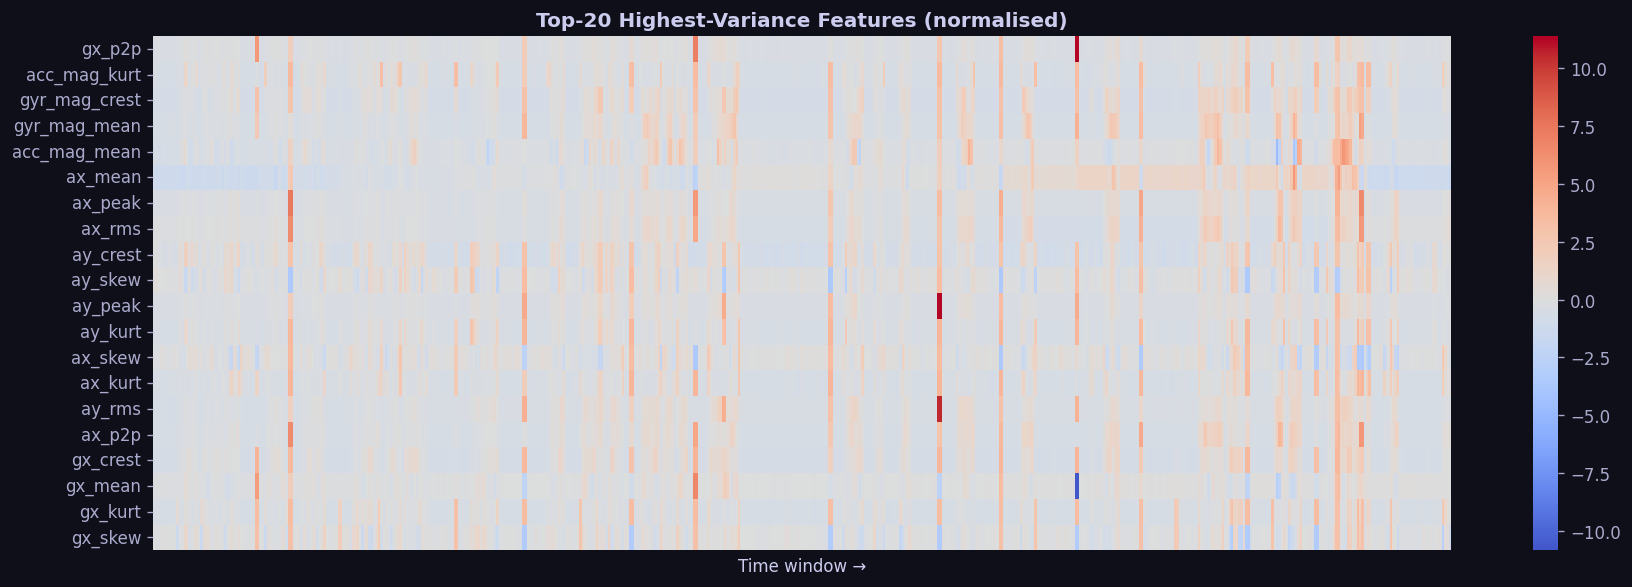

In [9]:
# ── Feature importance preview — heatmap of normalised features ───────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(feat_df[feat_cols].fillna(0))
X_scaled_df = pd.DataFrame(X_scaled, columns=feat_cols)

# Show top-variance features
top_feat = X_scaled_df.var().sort_values(ascending=False).head(20).index.tolist()

fig, ax = plt.subplots(figsize=(15, 5))
sns.heatmap(X_scaled_df[top_feat].T, ax=ax, cmap='coolwarm', center=0,
            xticklabels=False, yticklabels=top_feat, linewidths=0)
ax.set_xlabel('Time window →')
ax.set_title('Top-20 Highest-Variance Features (normalised)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('06_feature_heatmap.png', bbox_inches='tight', dpi=130)
plt.show()

## 6. Anomaly Detection

In [10]:
# ── 6A: Z-Score anomaly (sample level) ───────────────────────────────────────
Z_THRESH = 3.5
z_scores = np.abs(zscore(df[SENSOR_COLS].fillna(0)))
df['z_anomaly'] = (z_scores > Z_THRESH).any(axis=1).astype(int)

print(f'Z-score anomalies (>{Z_THRESH}σ): {df["z_anomaly"].sum()} / {len(df)} samples '
      f'({df["z_anomaly"].mean()*100:.1f}%)')

# ── 6B: Isolation Forest (window level) ──────────────────────────────────────
iso = IsolationForest(n_estimators=200, contamination=0.05, random_state=42)
iso.fit(X_scaled)
iso_pred = iso.predict(X_scaled)          # -1 = anomaly, 1 = normal
iso_score = iso.decision_function(X_scaled)

feat_df['iso_label'] = np.where(iso_pred == -1, 'Anomaly', 'Normal')
feat_df['iso_score'] = iso_score

print(f'\nIsolation Forest anomalous windows: '
      f'{(iso_pred==-1).sum()} / {len(feat_df)} '
      f'({(iso_pred==-1).mean()*100:.1f}%)')

Z-score anomalies (>3.5σ): 309 / 13750 samples (2.2%)

Isolation Forest anomalous windows: 28 / 548 (5.1%)


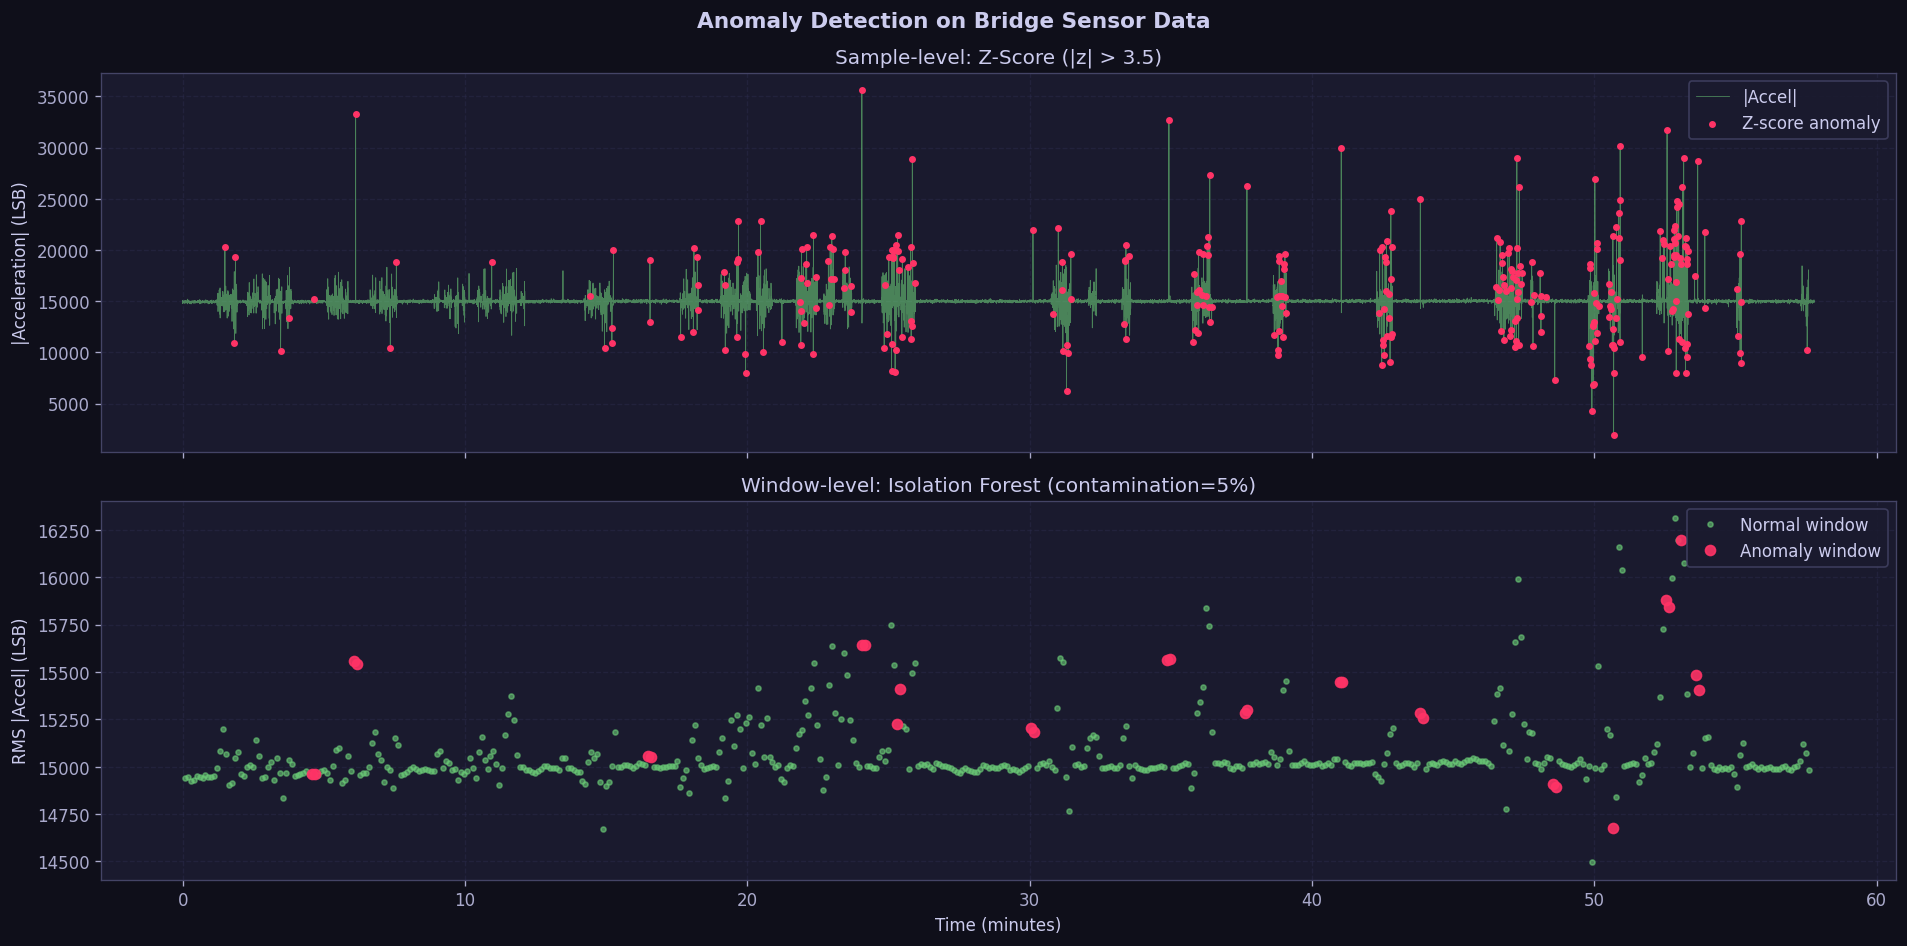

In [11]:
# ── 6C: Visualise anomalies on acceleration magnitude ────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle('Anomaly Detection on Bridge Sensor Data', fontsize=13, fontweight='bold')

# Sample-level Z-score
t = df['elapsed_sec'] / 60
axes[0].plot(t, df['acc_mag'], color='#6bcb77', lw=0.5, alpha=0.6, label='|Accel|')
axes[0].scatter(t[df['z_anomaly']==1], df.loc[df['z_anomaly']==1, 'acc_mag'],
                color='#ff3366', s=10, zorder=5, label='Z-score anomaly')
axes[0].set_ylabel('|Acceleration| (LSB)')
axes[0].legend()
axes[0].grid(True)
axes[0].set_title('Sample-level: Z-Score (|z| > 3.5)')

# Window-level Isolation Forest
norm_mask = feat_df['iso_label'] == 'Normal'
anom_mask = feat_df['iso_label'] == 'Anomaly'
axes[1].plot(feat_df.loc[norm_mask, 'time_min'], feat_df.loc[norm_mask, 'acc_mag_rms'],
             'o', color='#6bcb77', ms=3, alpha=0.6, label='Normal window')
axes[1].plot(feat_df.loc[anom_mask, 'time_min'], feat_df.loc[anom_mask, 'acc_mag_rms'],
             'o', color='#ff3366', ms=6, alpha=0.9, label='Anomaly window')
axes[1].set_xlabel('Time (minutes)')
axes[1].set_ylabel('RMS |Accel| (LSB)')
axes[1].legend()
axes[1].grid(True)
axes[1].set_title('Window-level: Isolation Forest (contamination=5%)')

plt.tight_layout()
plt.savefig('07_anomaly_detection.png', bbox_inches='tight', dpi=130)
plt.show()

## 7. SW-420 Vibration Event Analysis

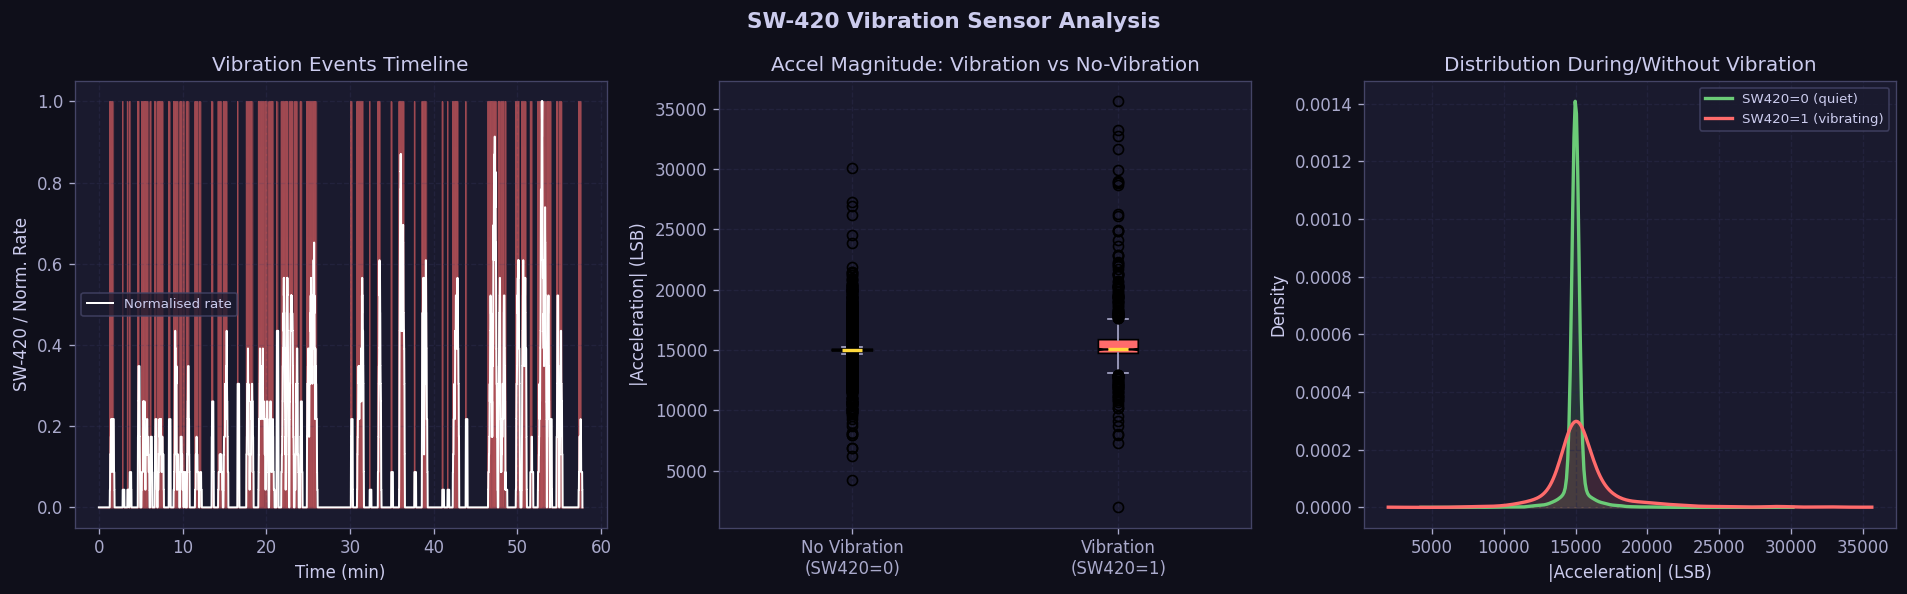

Mann-Whitney U test — p-value: 1.9043e-08
Conclusion: Significant difference ✅


In [12]:
# ── 7A: Vibration events over time ───────────────────────────────────────────
# Rolling vibration rate (events per minute)
df['vib_rate'] = df['sw420'].rolling(window=50, min_periods=1).mean() * avg_fs * 60

# Compare accel magnitude during vibration vs no-vibration
vib_on  = df[df['sw420'] == 1]['acc_mag']
vib_off = df[df['sw420'] == 0]['acc_mag']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('SW-420 Vibration Sensor Analysis', fontsize=13, fontweight='bold')

# Timeline of events
axes[0].plot(df['elapsed_sec']/60, df['sw420'], color='#ff6b6b', lw=0.5, alpha=0.4)
axes[0].fill_between(df['elapsed_sec']/60, df['sw420'], color='#ff6b6b', alpha=0.3)
axes[0].plot(df['elapsed_sec']/60, df['vib_rate']/df['vib_rate'].max(),
             color='white', lw=1.2, label='Normalised rate')
axes[0].set_xlabel('Time (min)')
axes[0].set_ylabel('SW-420 / Norm. Rate')
axes[0].set_title('Vibration Events Timeline')
axes[0].legend(fontsize=8)
axes[0].grid(True)

# Box plot comparison
bp_data = [vib_off.values, vib_on.values]
bp = axes[1].boxplot(bp_data, labels=['No Vibration\n(SW420=0)', 'Vibration\n(SW420=1)'],
                     patch_artist=True, notch=True,
                     boxprops=dict(facecolor='#1a1a2e'),
                     medianprops=dict(color='#ffd93d', lw=2),
                     whiskerprops=dict(color='#aaaacc'),
                     capprops=dict(color='#aaaacc'))
bp['boxes'][0].set_facecolor('#6bcb77')
bp['boxes'][1].set_facecolor('#ff6b6b')
axes[1].set_ylabel('|Acceleration| (LSB)')
axes[1].set_title('Accel Magnitude: Vibration vs No-Vibration')
axes[1].grid(True)

# KDE
from scipy.stats import gaussian_kde
for vals, label, color in [(vib_off, 'SW420=0 (quiet)', '#6bcb77'),
                            (vib_on,  'SW420=1 (vibrating)', '#ff6b6b')]:
    kde = gaussian_kde(vals, bw_method=0.3)
    xs = np.linspace(vals.min(), vals.max(), 300)
    axes[2].plot(xs, kde(xs), label=label, color=color, lw=2)
    axes[2].fill_between(xs, kde(xs), alpha=0.15, color=color)

axes[2].set_xlabel('|Acceleration| (LSB)')
axes[2].set_ylabel('Density')
axes[2].set_title('Distribution During/Without Vibration')
axes[2].legend(fontsize=8)
axes[2].grid(True)

plt.tight_layout()
plt.savefig('08_vibration_analysis.png', bbox_inches='tight', dpi=130)
plt.show()

from scipy.stats import mannwhitneyu
stat, p = mannwhitneyu(vib_on, vib_off, alternative='two-sided')
print(f'Mann-Whitney U test — p-value: {p:.4e}')
print('Conclusion:', 'Significant difference ✅' if p < 0.05 else 'No significant difference ❌')

## 8. Structural Health Index (SHI)

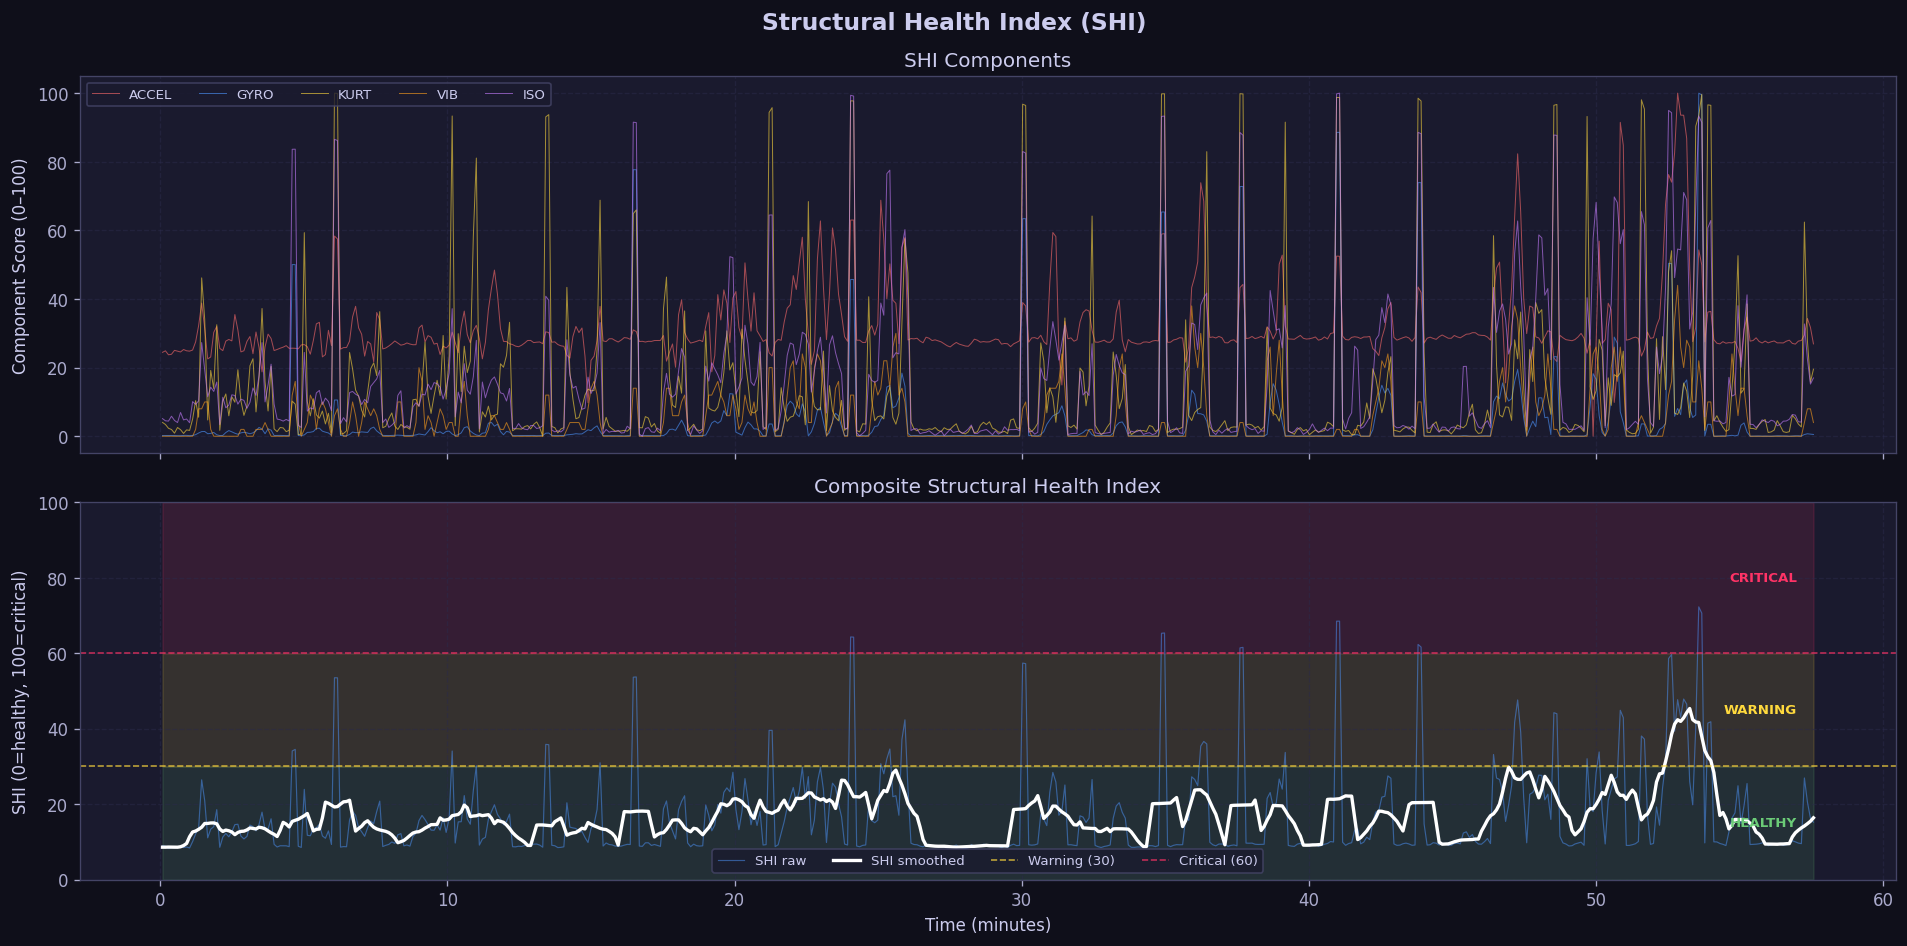

Mean SHI: 16.9 | Peak SHI: 45.4 | Overall zone: HEALTHY


In [13]:
# ── Composite Structural Health Index (0 = healthy, 100 = critical) ───────────
#
# Components:
#  1. Acceleration RMS deviation from baseline
#  2. Gyroscope RMS deviation from baseline
#  3. Kurtosis (impulsiveness — spikes = structural impacts)
#  4. Vibration event ratio
#  5. Isolation Forest anomaly score (inverted)

def norm_0_100(s):
    """Min-max normalise to [0, 100]"""
    r = s - s.min()
    return r / (r.max() + 1e-9) * 100

feat_df['shi_accel']  = norm_0_100(feat_df['acc_mag_rms'])
feat_df['shi_gyro']   = norm_0_100(feat_df['gyr_mag_rms'])
feat_df['shi_kurt']   = norm_0_100(feat_df['acc_mag_kurt'].clip(-5, 50))
feat_df['shi_vib']    = feat_df['vib_ratio'] * 100
feat_df['shi_iso']    = norm_0_100(-feat_df['iso_score'])   # more negative = more anomalous

# Weighted average
WEIGHTS = {'shi_accel': 0.30, 'shi_gyro': 0.20,
           'shi_kurt':  0.20, 'shi_vib': 0.15, 'shi_iso': 0.15}

feat_df['SHI'] = sum(feat_df[k] * v for k, v in WEIGHTS.items())
feat_df['SHI_smooth'] = feat_df['SHI'].rolling(10, center=True, min_periods=1).mean()

# Plot
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle('Structural Health Index (SHI)', fontsize=14, fontweight='bold')

t_win = feat_df['time_min']

# Component breakdown
for comp, color in [('shi_accel','#ff6b6b'), ('shi_gyro','#4d96ff'),
                     ('shi_kurt','#ffd93d'),  ('shi_vib','#ff9f1c'),
                     ('shi_iso','#c77dff')]:
    axes[0].plot(t_win, feat_df[comp], lw=0.6, alpha=0.6, color=color,
                 label=comp.replace('shi_', '').upper())
axes[0].set_ylabel('Component Score (0–100)')
axes[0].legend(ncol=5, fontsize=8)
axes[0].grid(True)
axes[0].set_title('SHI Components')

# Composite SHI with threshold bands
axes[1].fill_between(t_win, 0,  30, alpha=0.12, color='#6bcb77')
axes[1].fill_between(t_win, 30, 60, alpha=0.12, color='#ffd93d')
axes[1].fill_between(t_win, 60, 100,alpha=0.12, color='#ff3366')
axes[1].plot(t_win, feat_df['SHI'],        color='#4d96ff', lw=0.7, alpha=0.5, label='SHI raw')
axes[1].plot(t_win, feat_df['SHI_smooth'], color='white',   lw=2,               label='SHI smoothed')
axes[1].axhline(30, color='#ffd93d', lw=1, linestyle='--', alpha=0.7, label='Warning (30)')
axes[1].axhline(60, color='#ff3366', lw=1, linestyle='--', alpha=0.7, label='Critical (60)')
axes[1].set_ylim(0, 100)
axes[1].set_xlabel('Time (minutes)')
axes[1].set_ylabel('SHI (0=healthy, 100=critical)')
axes[1].legend(ncol=4, fontsize=8)
axes[1].grid(True)
axes[1].set_title('Composite Structural Health Index')

# Add zone labels
for y, label, color in [(15,'HEALTHY','#6bcb77'), (45,'WARNING','#ffd93d'), (80,'CRITICAL','#ff3366')]:
    axes[1].text(t_win.iloc[-1]*0.99, y, label, ha='right', va='center',
                 color=color, fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('09_structural_health_index.png', bbox_inches='tight', dpi=130)
plt.show()

shi_max = feat_df['SHI_smooth'].max()
shi_mean = feat_df['SHI_smooth'].mean()
zone = 'HEALTHY' if shi_mean < 30 else ('WARNING' if shi_mean < 60 else 'CRITICAL')
print(f'Mean SHI: {shi_mean:.1f} | Peak SHI: {shi_max:.1f} | Overall zone: {zone}')

## 9. ML Classification — Normal vs High-Stress Windows

In [14]:
# Label: 1 = anomalous window (Isolation Forest OR vibration event), 0 = normal
feat_df['label'] = ((feat_df['iso_label'] == 'Anomaly') | (feat_df['vib_event'] == 1)).astype(int)

print(f'Normal windows  : {(feat_df["label"]==0).sum()}')
print(f'High-stress windows: {(feat_df["label"]==1).sum()}')

X = feat_df[feat_cols].fillna(0)
y = feat_df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

scaler2 = StandardScaler()
X_train_s = scaler2.fit_transform(X_train)
X_test_s  = scaler2.transform(X_test)

rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf.fit(X_train_s, y_train)
y_pred = rf.predict(X_test_s)

print('\n── Classification Report ──')
print(classification_report(y_test, y_pred, target_names=['Normal', 'High-Stress']))

Normal windows  : 297
High-stress windows: 251

── Classification Report ──
              precision    recall  f1-score   support

      Normal       0.94      0.85      0.89        74
 High-Stress       0.84      0.94      0.89        63

    accuracy                           0.89       137
   macro avg       0.89      0.89      0.89       137
weighted avg       0.90      0.89      0.89       137



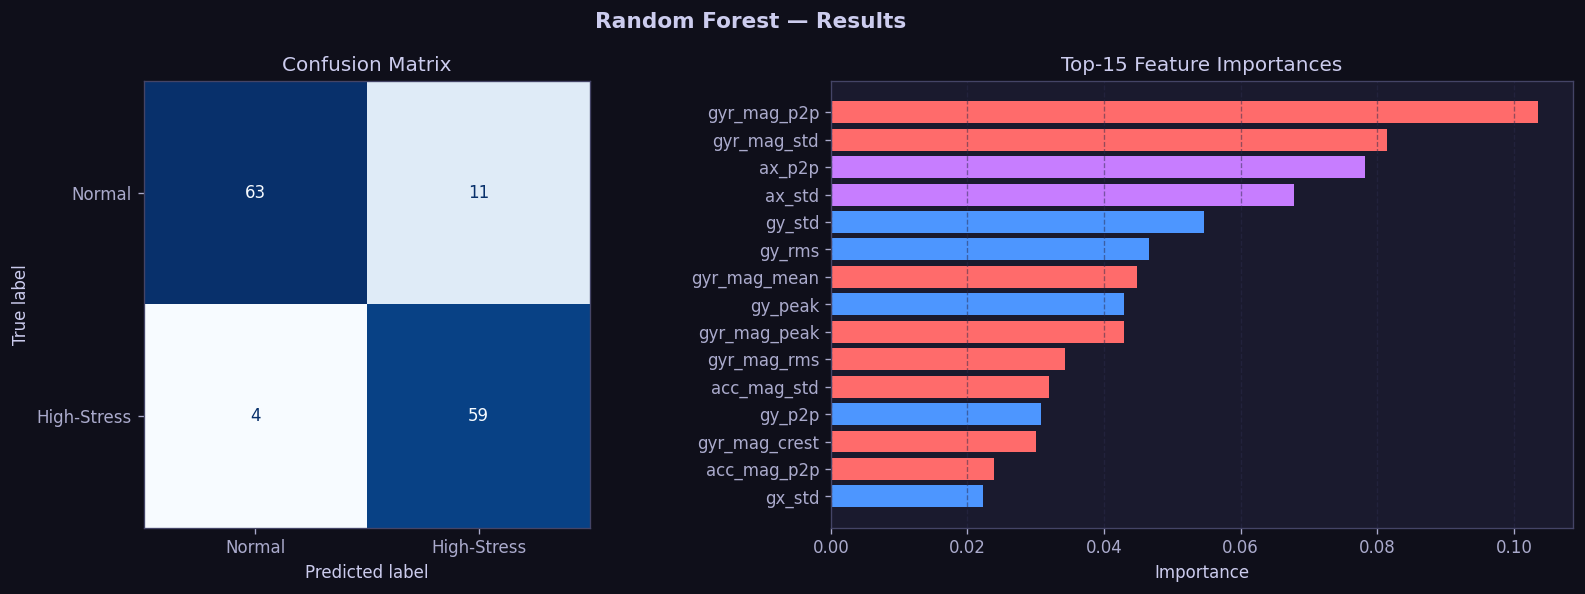

In [15]:
# ── Confusion matrix + Feature importance ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Random Forest — Results', fontsize=13, fontweight='bold')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'High-Stress'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_facecolor('#1a1a2e')
axes[0].set_title('Confusion Matrix')

# Feature importance (top 15)
importances = pd.Series(rf.feature_importances_, index=feat_cols).sort_values(ascending=True).tail(15)
colors_bar = ['#ff6b6b' if 'acc' in i or 'mag' in i else
              '#4d96ff' if 'gyr' in i or 'gz' in i or 'gx' in i or 'gy' in i else
              '#ffd93d' if 'kurt' in i or 'crest' in i else
              '#c77dff' for i in importances.index]
axes[1].barh(importances.index, importances.values, color=colors_bar, edgecolor='none')
axes[1].set_xlabel('Importance')
axes[1].set_title('Top-15 Feature Importances')
axes[1].grid(True, axis='x')

plt.tight_layout()
plt.savefig('10_random_forest.png', bbox_inches='tight', dpi=130)
plt.show()

## 10. PCA Visualization

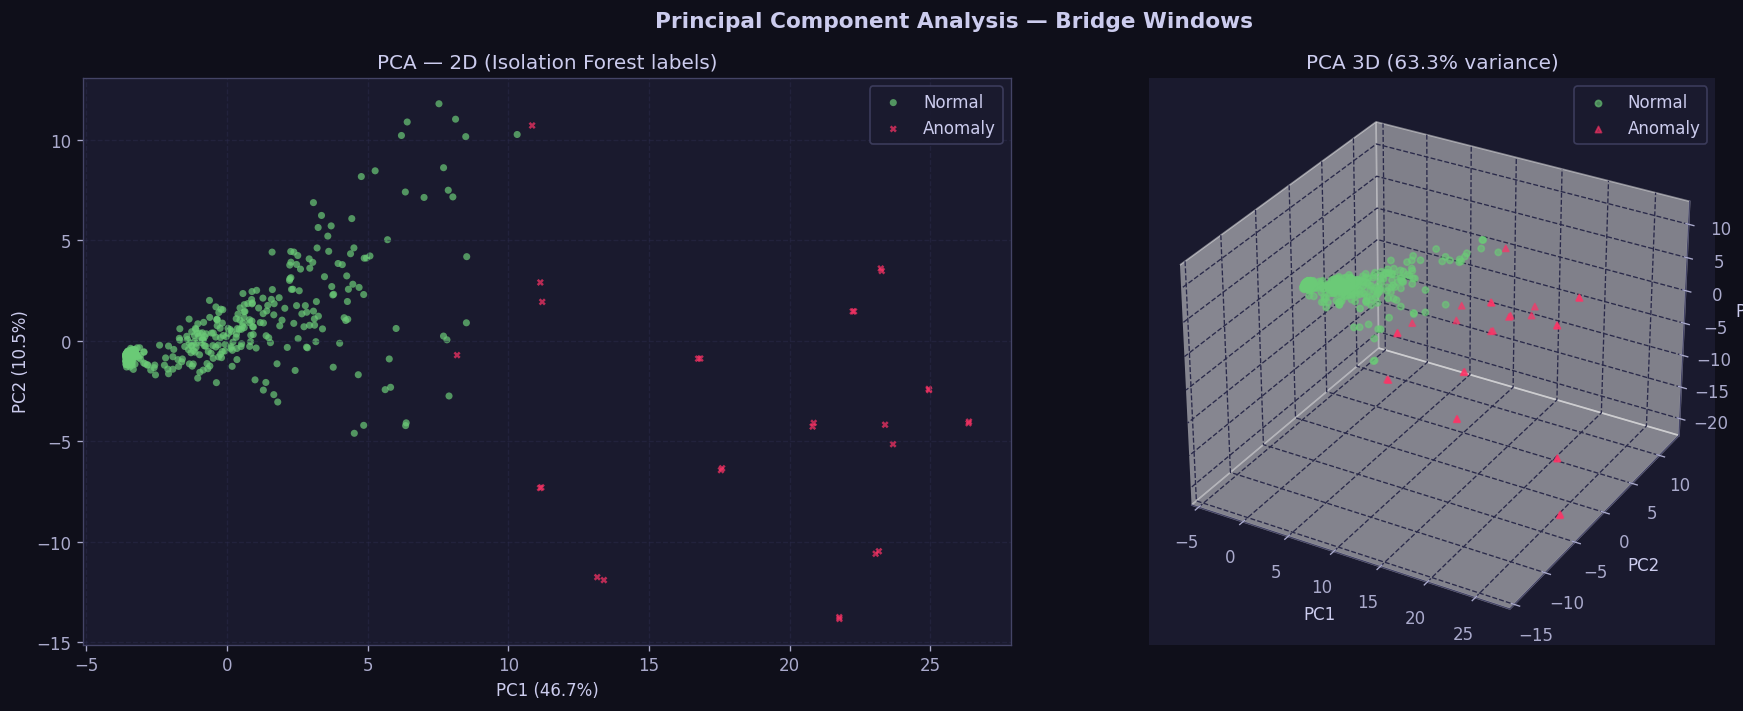

Cumulative variance — PC1: 46.7%, PC1+2: 57.1%, PC1+2+3: 63.3%


In [16]:
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)
evr = pca.explained_variance_ratio_

fig = plt.figure(figsize=(16, 6))

# ── 2D scatter ────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(1, 2, 1)
for label, color, marker in [('Normal','#6bcb77','o'), ('Anomaly','#ff3366','X')]:
    mask = feat_df['iso_label'] == label
    ax2.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=color, s=18, alpha=0.7, label=label, marker=marker, edgecolors='none')
ax2.set_xlabel(f'PC1 ({evr[0]*100:.1f}%)')
ax2.set_ylabel(f'PC2 ({evr[1]*100:.1f}%)')
ax2.set_title('PCA — 2D (Isolation Forest labels)')
ax2.legend()
ax2.grid(True)

# ── 3D scatter ────────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(1, 2, 2, projection='3d')
ax3.set_facecolor('#1a1a2e')
for label, color, marker in [('Normal','#6bcb77','o'), ('Anomaly','#ff3366','^')]:
    mask = feat_df['iso_label'] == label
    ax3.scatter(X_pca[mask, 0], X_pca[mask, 1], X_pca[mask, 2],
                c=color, s=14, alpha=0.6, label=label, marker=marker)
ax3.set_xlabel(f'PC1')
ax3.set_ylabel(f'PC2')
ax3.set_zlabel(f'PC3')
ax3.set_title(f'PCA 3D ({sum(evr[:3])*100:.1f}% variance)')
ax3.legend()

fig.suptitle('Principal Component Analysis — Bridge Windows', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('11_pca.png', bbox_inches='tight', dpi=130)
plt.show()

print(f'Cumulative variance — PC1: {evr[0]*100:.1f}%, PC1+2: {sum(evr[:2])*100:.1f}%, PC1+2+3: {sum(evr[:3])*100:.1f}%')

## 11. Summary Dashboard

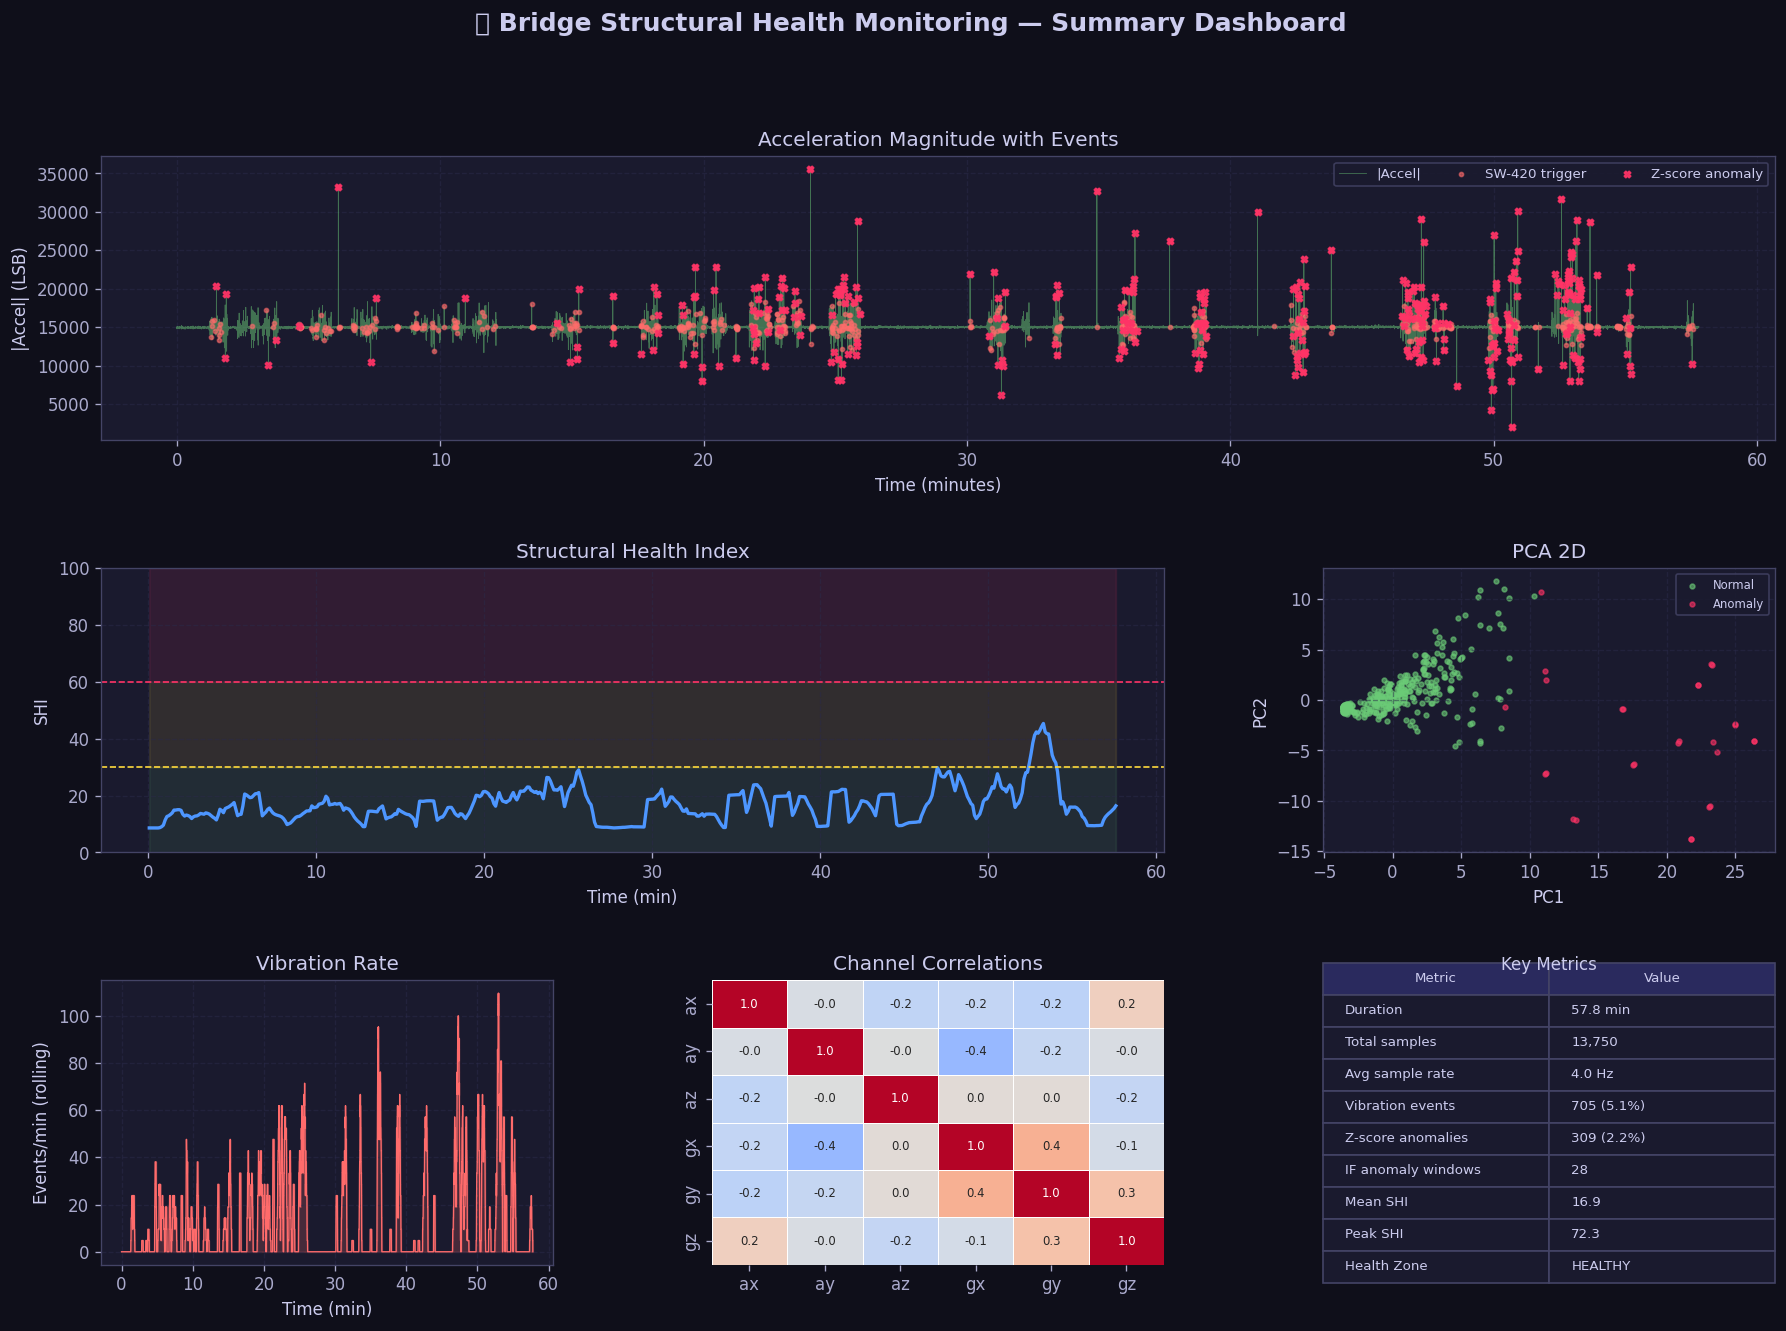

✅ All plots saved. Dashboard complete.


In [17]:
fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle('🌉 Bridge Structural Health Monitoring — Summary Dashboard', fontsize=15, fontweight='bold')

# ── Panel 1: Acc magnitude + vibration events ─────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
t = df['elapsed_sec'] / 60
ax1.plot(t, df['acc_mag'], color='#6bcb77', lw=0.5, alpha=0.5, label='|Accel|')
ax1.scatter(t[df['sw420']==1], df.loc[df['sw420']==1, 'acc_mag'],
            color='#ff6b6b', s=6, zorder=5, label='SW-420 trigger', alpha=0.6)
ax1.scatter(t[df['z_anomaly']==1], df.loc[df['z_anomaly']==1, 'acc_mag'],
            color='#ff3366', s=15, marker='X', zorder=6, label='Z-score anomaly', alpha=0.9)
ax1.set_xlabel('Time (minutes)')
ax1.set_ylabel('|Accel| (LSB)')
ax1.set_title('Acceleration Magnitude with Events')
ax1.legend(ncol=3, fontsize=8)
ax1.grid(True)

# ── Panel 2: SHI ──────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, :2])
t_win = feat_df['time_min']
ax2.fill_between(t_win, 0, 30, alpha=0.1, color='#6bcb77')
ax2.fill_between(t_win, 30, 60, alpha=0.1, color='#ffd93d')
ax2.fill_between(t_win, 60, 100, alpha=0.1, color='#ff3366')
ax2.plot(t_win, feat_df['SHI_smooth'], color='#4d96ff', lw=2)
ax2.axhline(30, color='#ffd93d', lw=1, linestyle='--')
ax2.axhline(60, color='#ff3366', lw=1, linestyle='--')
ax2.set_ylim(0, 100)
ax2.set_title('Structural Health Index')
ax2.set_ylabel('SHI')
ax2.set_xlabel('Time (min)')
ax2.grid(True)

# ── Panel 3: PCA 2D ───────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 2])
for label, color in [('Normal','#6bcb77'), ('Anomaly','#ff3366')]:
    mask = feat_df['iso_label'] == label
    ax3.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, s=8, alpha=0.6, label=label)
ax3.set_title('PCA 2D')
ax3.set_xlabel('PC1')
ax3.set_ylabel('PC2')
ax3.legend(fontsize=7)
ax3.grid(True)

# ── Panel 4: Vibration rate ───────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
ax4.plot(t, df['vib_rate'], color='#ff6b6b', lw=0.8)
ax4.fill_between(t, df['vib_rate'], alpha=0.2, color='#ff6b6b')
ax4.set_title('Vibration Rate')
ax4.set_xlabel('Time (min)')
ax4.set_ylabel('Events/min (rolling)')
ax4.grid(True)

# ── Panel 5: Correlation ──────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
corr_small = df[['ax','ay','az','gx','gy','gz']].corr()
sns.heatmap(corr_small, annot=True, fmt='.1f', cmap='coolwarm',
            center=0, ax=ax5, annot_kws={'size':7}, linewidths=0.5,
            cbar=False)
ax5.set_title('Channel Correlations')

# ── Panel 6: Stats table ──────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 2])
ax6.axis('off')
stats = [
    ['Metric', 'Value'],
    ['Duration', f"{duration_min:.1f} min"],
    ['Total samples', f"{len(df):,}"],
    ['Avg sample rate', f"{avg_fs:.1f} Hz"],
    ['Vibration events', f"{df['sw420'].sum()} ({df['sw420'].mean()*100:.1f}%)"],
    ['Z-score anomalies', f"{df['z_anomaly'].sum()} ({df['z_anomaly'].mean()*100:.1f}%)"],
    ['IF anomaly windows', f"{(feat_df['iso_label']=='Anomaly').sum()}"],
    ['Mean SHI', f"{feat_df['SHI'].mean():.1f}"],
    ['Peak SHI', f"{feat_df['SHI'].max():.1f}"],
    ['Health Zone', zone],
]
table = ax6.table(cellText=stats[1:], colLabels=stats[0],
                   loc='center', cellLoc='left')
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.6)
for (r, c), cell in table.get_celld().items():
    cell.set_facecolor('#1a1a2e')
    cell.set_edgecolor('#444466')
    cell.set_text_props(color='#ccccee')
    if r == 0:
        cell.set_facecolor('#2a2a5e')
ax6.set_title('Key Metrics', fontsize=10)

plt.savefig('12_dashboard.png', bbox_inches='tight', dpi=140)
plt.show()
print('✅ All plots saved. Dashboard complete.')

## 12. Interpretation Guide

| Metric | What it tells you |
|---|---|
| **acc_mag** | Overall motion energy. Spikes = load events (someone walking on bridge, tap test). |
| **gyr_mag** | Rotational/torsional motion. High values = bridge flexing. |
| **SW-420** | Binary vibration switch. Good for detecting impact/resonance events. |
| **FFT dominant frequencies** | Natural/resonant frequency of your bridge. Shift over time = damage indicator. |
| **Kurtosis** | >3 = impulsive (sharp hits); structural cracks often raise this. |
| **SHI** | 0–30 = healthy, 30–60 = monitor, 60–100 = investigate. |
| **Isolation Forest** | Windows that differ most from the baseline — potential damage events. |

### Next steps for real SHM
- **Compare multiple load scenarios** (empty, loaded, dynamic) as separate recordings
- **Track dominant FFT frequency** over weeks — downward shift = stiffness loss
- **Add a piezoelectric sensor** for higher-frequency (100Hz+) crack detection
- **Baseline vs current SHI trend** — the real power is in comparing recordings over time